In [45]:
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
model = joblib.load("../models/best_model.pkl")
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

In [47]:
sample = """
Urgently hiring.
Work from home.
Earn $5000 every week.
No experience required.
Apply immediately.
"""

In [48]:
X_text = tfidf.transform([sample])

In [49]:
from scipy.sparse import hstack

structured = [[1,0,0]]

X = hstack([
    X_text,
    structured
])

In [50]:
explainer = shap.LinearExplainer(
    model,
    X
)

In [51]:
shap_values = explainer.shap_values(X)

In [52]:
feature_names = list(tfidf.get_feature_names_out())

feature_names.extend([
    "telecommuting",
    "has_logo",
    "has_questions"
])

In [53]:
import shap
print(shap.__version__)

0.52.0


In [54]:
print(type(X))
print(type(shap_values))

<class 'scipy.sparse._coo.coo_matrix'>
<class 'numpy.ndarray'>


In [55]:
X_dense = X.toarray()

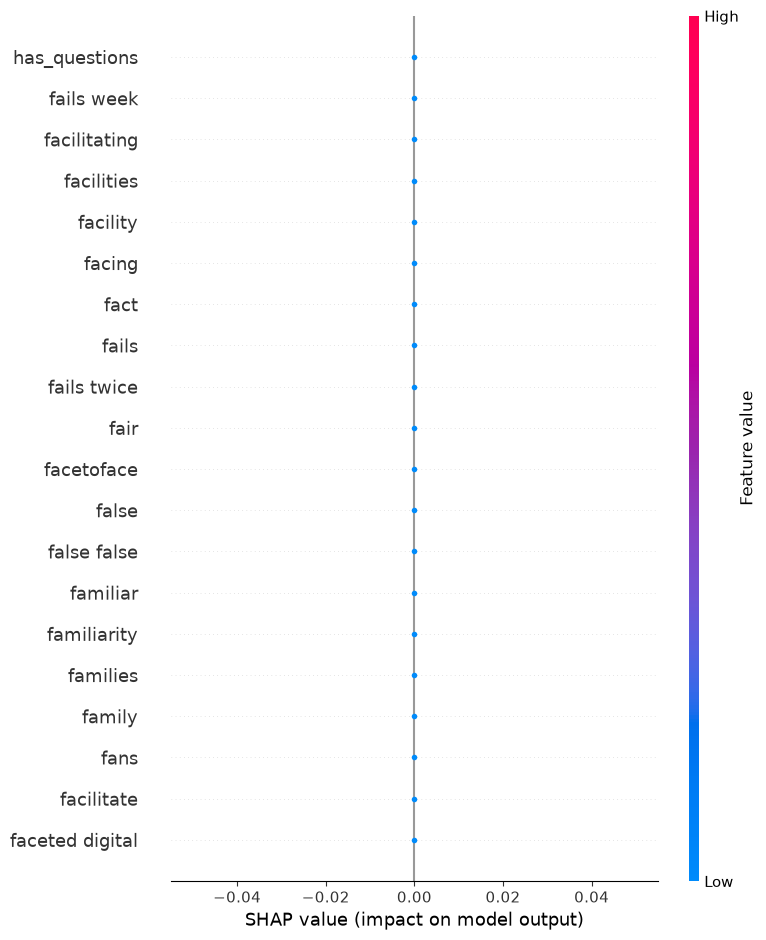

In [56]:
shap.summary_plot(
    shap_values,
    X_dense,
    feature_names=feature_names
)